📥 Executando consulta Base 2 - alocação e pessoas...
Index(['ID_Cota', 'DT_Alocacao', 'Tipo_Pessoa', 'Nome_Produto', 'CPF_CNPJ',
       'Safra_Alocacao'],
      dtype='object')
Index(['ID_Cota', 'DT_Alocacao', 'Tipo_Pessoa', 'Nome_Produto', 'CPF_CNPJ',
       'Safra_Alocacao', 'Data', 'Score_Credito', 'Tipo', 'Diferenca_Datas'],
      dtype='object')
Index(['ID_Cota', 'DT_Alocacao', 'Tipo_Pessoa', 'Nome_Produto', 'CPF_CNPJ',
       'Safra_Alocacao', 'Data', 'Score_Credito', 'Tipo', 'Diferenca_Datas',
       'Faixa_Atraso'],
      dtype='object')
Total de registros para 202505: 0
[]


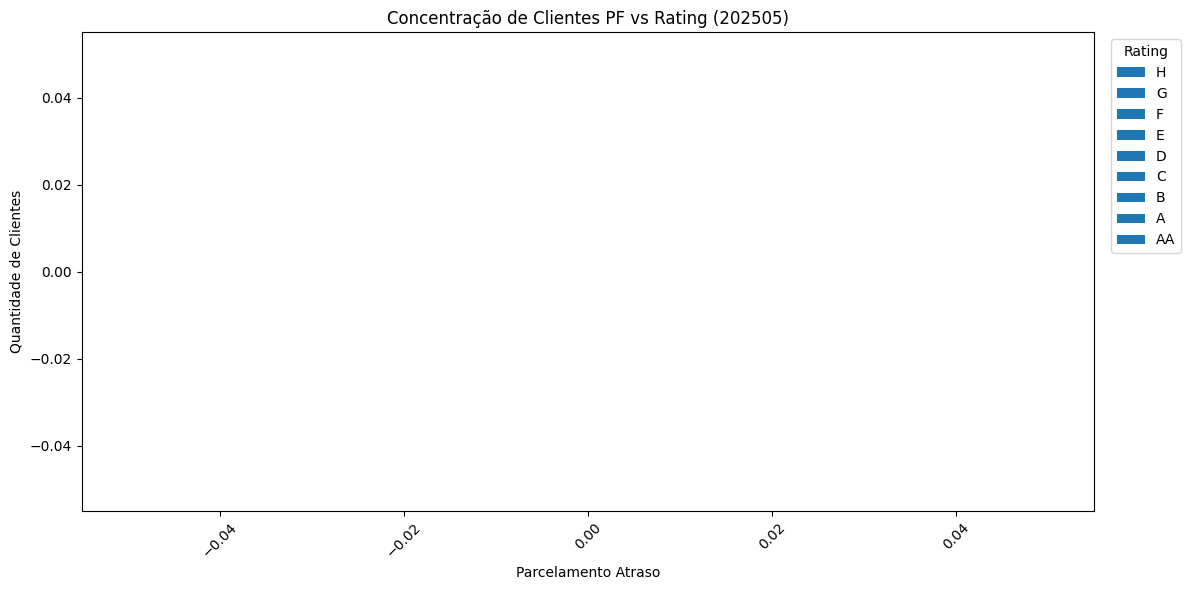

In [7]:
# Bibliotecas utilizadas
import os
import pandas as pd
import pyodbc
import warnings
import matplotlib.pyplot as plt

# Função para retirar os Warnings
warnings.filterwarnings('ignore')

# Pegando usuário e caminho base para senhas
usuario = os.getenv('USERNAME')
path_senhas = fr'C:\Users\{usuario}\OneDrive - CAIXA Consórcio\Documentos\SENHA_BANCO_DADOS'

# Carregar credenciais
df_senhas = pd.read_excel(fr'{path_senhas}\SENHAS.xlsx')
server, database, username, password = df_senhas.iloc[0, 0:4]

# Conexão com o SQL Server
conn = pyodbc.connect(
    f'DRIVER={{ODBC Driver 17 for SQL Server}};SERVER={server};DATABASE={database};UID={username};PWD={password}'
)

# Funções utilizadas
def faixas_score_pf():
    intervalos = [0, 337, 416, 476, 524, 567, 607, 651, 701, 1000]
    lista_rating = ['H', 'G', 'F', 'E', 'D', 'C', 'B', 'A', 'AA']
    return intervalos, lista_rating

def faixas_score_pj():
    intervalos = [0, 187, 281, 359, 426, 495, 562, 631, 706, 1000]
    lista_rating = ['H', 'G', 'F', 'E', 'D', 'C', 'B', 'A', 'AA']
    return intervalos, lista_rating

def define_rating(score, intervalos, lista_rating):
    for i in range(len(intervalos) - 1):
        if intervalos[i] < score <= intervalos[i + 1]:
            return lista_rating[i]
    return None

# --- BASE 2: buscar dados de score e rating ---
query_base2 = """
SELECT
    a.ID_Cota,
    a.DT_Alocacao,
    a.Tipo_Pessoa,
    c.NM_Produto as Nome_Produto,
    b.CD_InscricaoNacional AS CPF_CNPJ
FROM [dbo].[FT0002_VendaAlocacoes] a
LEFT JOIN [dbo].[DM0013_Pessoas] b ON a.ID_Pessoa = b.ID_Pessoa
LEFT JOIN [dbo].[DM0002_Produtos] c on a.ID_Produto = c.ID_Produto
where a.DT_Alocacao >= '2024-05-01'
and a.DT_Alocacao <= '2025-05-30'
"""

print("📥 Executando consulta Base 2 - alocação e pessoas...")
df_base2 = pd.read_sql(query_base2, conn)

# Função para tratar documento (remover parte decimal)
def tratando_documento(val):
    val = float(val)
    val = str(val).split('.')[0]
    return val

def safra_alocacao(val):
    val = str(val)[0:7]
    return(val)

df_base2['CPF_CNPJ'] = df_base2['CPF_CNPJ'].apply(tratando_documento)
df_base2['DT_Alocacao'] = pd.to_datetime(df_base2['DT_Alocacao'], format='%Y-%m-%d')

# Criar a coluna Safra_Alocacao
df_base2['Safra_Alocacao'] = df_base2['DT_Alocacao'].apply(safra_alocacao)

# Verificar as colunas para garantir que 'Safra_Alocacao' foi criada
print(df_base2.columns)

# Carregar base de score de crédito (arquivo CSV externo)
path_score = fr'C:\Users\{usuario}\CAIXA Consórcio\Risco de Crédito e Antifraude - Documentos\MODELOS\MODELAGEM\SCORE_CREDITO_BOA_VISTA\BASES_HISTORICAS'
df_score = pd.read_csv(fr'{path_score}\score_credito_full.csv', delimiter=";")
df_score = df_score[df_score['Score_Credito'] > 2]
df_score['CPF_CNPJ'] = df_score['CPF_CNPJ'].apply(tratando_documento)
df_score['Data'] = pd.to_datetime(df_score['Data'], format='%Y-%m-%d')

# Fazer merge entre base2 e score pelo CPF/CNPJ
df_base2 = df_base2.merge(df_score, how='left', on='CPF_CNPJ')

# Retirando Scores diferentes de nulo
df_base2 = df_base2[df_base2['Score_Credito'].notna()]

# Calcular diferença de datas para pegar a mais próxima
df_base2['Diferenca_Datas'] = abs(df_base2['DT_Alocacao'] - df_base2['Data']).dt.days

# Verificando as colunas após o cálculo da 'Diferenca_Datas'
print(df_base2.columns)

# Criar a coluna Faixa_Atraso
def define_faixa_atraso(dias_atraso):
    if dias_atraso <= 30:
        return "1 Parc Atraso"
    elif 30 < dias_atraso <= 60:
        return "2 Parc Atraso"
    elif 60 < dias_atraso <= 90:
        return "3 Parc Atraso"
    else:
        return "Atraso Superior"

# Aplicar a função para criar a coluna Faixa_Atraso
df_base2['Faixa_Atraso'] = df_base2['Diferenca_Datas'].apply(define_faixa_atraso)

# Verificar novamente as colunas
print(df_base2.columns)

# Pegando a Faixa de PF
intervalos_pf, lista_rating_pf = faixas_score_pf()

# Criando base Silver
# Visão Geral
df_silver_geral = df_base2[['DT_Alocacao', 'Tipo_Pessoa', 'CPF_CNPJ', 'Score_Credito']]
df_silver_geral['Safra_Alocacao'] = df_silver_geral['DT_Alocacao'].apply(safra_alocacao)
df_silver_geral = df_silver_geral.drop(columns=['DT_Alocacao'])

# Média dos Score_Credito por Cliente + Safra_Alocacao
df_silver_geral = df_silver_geral.groupby(by=['CPF_CNPJ', 'Tipo_Pessoa', 'Safra_Alocacao']).mean().reset_index(level=['CPF_CNPJ', 'Tipo_Pessoa', 'Safra_Alocacao'])

# Coletar os Ratings
def atribui_rating(row):
    if pd.isna(row['Score_Credito']):
        return None
    if row['Tipo_Pessoa'] == 'F':
        return define_rating(row['Score_Credito'], intervalos_pf, lista_rating_pf)
df_silver_geral['Rating'] = df_silver_geral.apply(atribui_rating, axis=1)

# --- FILTRANDO DADOS PARA O MÊS 202505 --- 
df_silver_geral['Safra_Alocacao'] = df_silver_geral['Safra_Alocacao'].astype(str)
df_base2_202505 = df_base2[df_base2['Safra_Alocacao'] == '202505']

# Verificando se há dados para 202505
print(f"Total de registros para 202505: {len(df_base2_202505)}")

# Criando a coluna 'Rating' no df_base2_202505
df_base2_202505['Rating'] = df_base2_202505.apply(atribui_rating, axis=1)

# Verificar se os valores de 'Rating' estão sendo aplicados corretamente
print(df_base2_202505['Rating'].unique())

# Definir as cores para cada Rating
cores = {
    'AA': '#0c2c84',
    'A':  '#225ea8',
    'B':  '#1d91c0',
    'C':  '#41b6c4',
    'D':  '#7fcdbb',
    'E':  '#c7e9b4',
    'F':  '#ffffcc',
    'G':  '#fdae61',
    'H':  '#d73027'
}

# Agrupando os dados por Faixa_Atraso e Rating
df_agrupado_202505 = (
    df_base2_202505.groupby(['Faixa_Atraso', 'Rating'])
                   .size()
                   .unstack(fill_value=0)
                   .reindex(columns=lista_rating_pf, fill_value=0)
                   .sort_index()
)

# Total de clientes por Faixa Atraso
totais_parc = df_agrupado_202505.sum(axis=1)  # Total de cada "Faixa Atraso"

# 4. PLOT -------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 6))
bottom = [0] * len(df_agrupado_202505)
x_labels = df_agrupado_202505.index.astype(str)

# Gerar o gráfico com as barras empilhadas
for rating in lista_rating_pf:
    valores = df_agrupado_202505[rating]
    bars = ax.bar(x_labels, valores, bottom=bottom,
                  color=cores[rating], label=rating)

    # Escrever o percentual dentro das barras
    for i, (bar, valor) in enumerate(zip(bars, valores)):
        if valor > 0:
            pct = 100 * valor / totais_parc.iloc[i]
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bottom[i] + valor / 2,
                    f"{pct:.1f}%",             # Exibe o percentual
                    ha='center', va='center',
                    fontsize=9, color='black', fontweight='bold')
    bottom = [b + v for b, v in zip(bottom, valores)]

# 5. AJUSTES FINAIS ---------------------------------------------------------
ax.set_title("Concentração de Clientes PF vs Rating (202505)")
ax.set_xlabel("Parcelamento Atraso")
ax.set_ylabel("Quantidade de Clientes")     # A contagem dos clientes
ax.legend(title="Rating", bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
